Benjamin Arnold; 08/26/2026; Lab 1 -- Projectile Motion Solver.

Part A-- One-Dimensional Free-Fall

Final time is 4.529999999999948 s, and the final velocity is -44.43930000000012 m/s. The exact values are 4.515 s and -44.294 m/s, respectively.


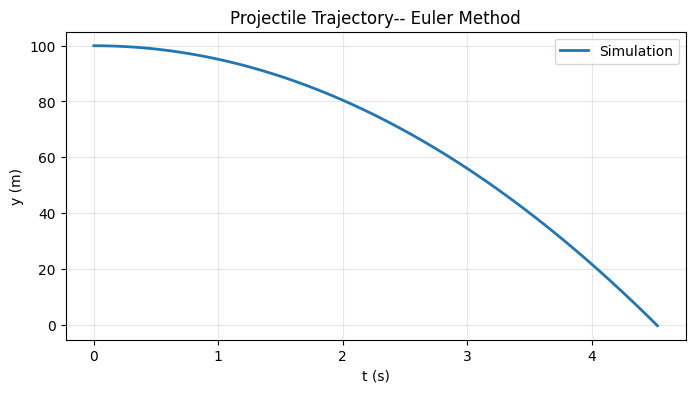

In [53]:
import numpy as np
import matplotlib.pyplot as plt

time_step=0.01
initial_height=100

def simulate_freefall(h,dt,g=9.81):
    y, vy=h,0
    t=0.0

    t_arr, y_arr, vy_arr=[t],[y],[vy]

    while y>=0:
        ay=-g
        y=y+vy*dt
        vy=vy+ay*dt
        t=t+dt

        t_arr.append(t)
        y_arr.append(y)
        vy_arr.append(vy)
    return t_arr,y_arr,vy_arr

t,y,vy=simulate_freefall(initial_height,time_step,g=9.81)
print(f'Final time is {t[-1]} s, and the final velocity is {vy[-1]} m/s. The exact values are 4.515 s and -44.294 m/s, respectively.')

plt.figure(figsize=(8, 4))
plt.plot(t, y, linewidth=2, label='Simulation')
plt.xlabel('t (s)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory-- Euler Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Notes: The exact values are roughly t=4.515 s and vy=-44.294 m/s. The numerical results for dt=0.1 are 
t=4.6 s and -45.126 m/s. The percentage error for each is 1.88%. For dt=1, the error is 32.88%, and for dt=0.001 the error is 0.327%.

Part B-- Two-Dimensional Projectile

The error in the range is 0.2355682137093795%, in the max height is 0.34709798741764625%, and in the flight time is 0.23556821370709102%.


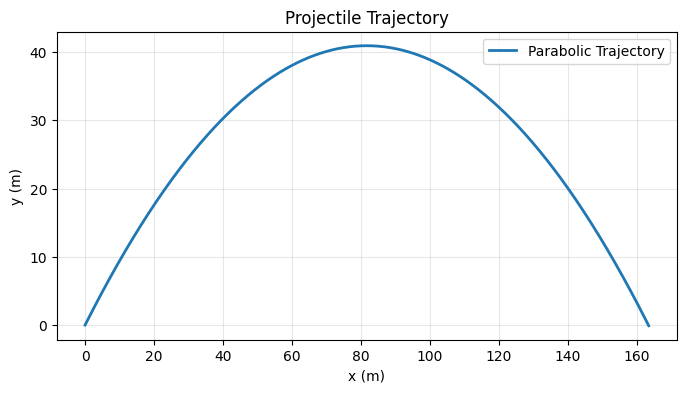

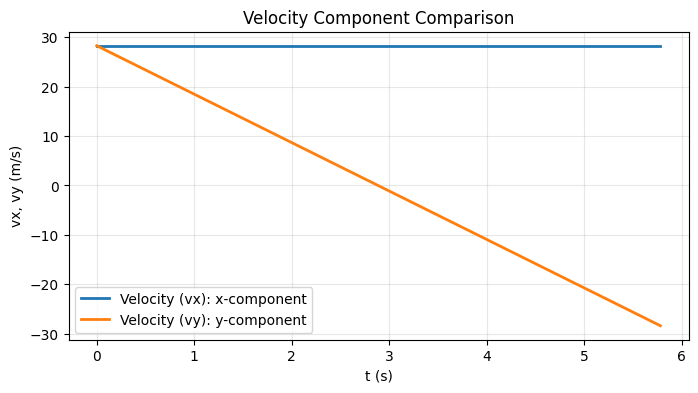

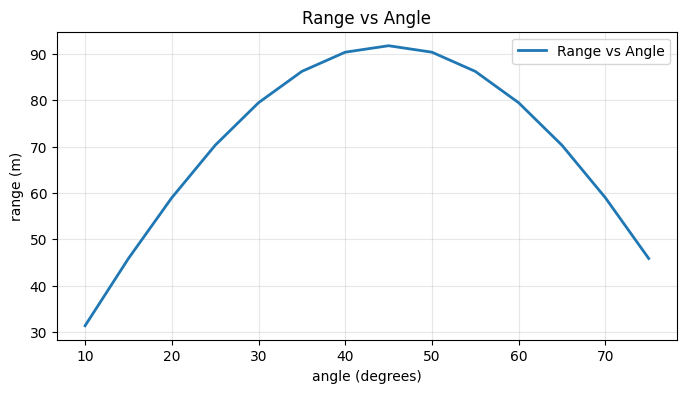

In [56]:
import numpy as np
import matplotlib.pyplot as plt

time_step=0.01
initial_velocity=40
initial_angle=45

def simulate_projectile_2d(v0,theta_deg,dt,g=9.81):
    ay,ax=-g,0
    x,y=0.0,0.0
    vx=v0*np.cos(theta_deg*np.pi/180)
    vy=v0*np.sin(theta_deg*np.pi/180)
    t=0.0

    t_arr,x_arr,y_arr,vy_arr,vx_arr=[t],[x],[y],[vy],[vx]

    while (y>=0):
        x=x+vx*dt
        y=y+vy*dt
        vx=vx+ax*dt
        vy=vy+ay*dt
        t=t+dt

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vy_arr.append(vy)
        vx_arr.append(vx)
    return t_arr,x_arr,y_arr,vx_arr,vy_arr

t,x,y,vx,vy=simulate_projectile_2d(initial_velocity,initial_angle,time_step,g=9.81)

def calculator(v0,theta_deg,a,b,c):
    rng=((v0)**2)*(np.sin(2*(theta_deg*np.pi/180)))/9.81
    max_height=((v0**2)*((np.sin(theta_deg*np.pi/180))**2))/(2*9.81)
    flight_time=(2*v0*(np.sin(theta_deg*np.pi/180)))/9.81

    rng_err=((np.max(a)-rng)/rng)*100
    max_height_err=((np.max(b)-max_height)/max_height)*100
    flight_time_err=((np.max(c)-flight_time)/flight_time)*100

    return rng, max_height,flight_time, rng_err,max_height_err,flight_time_err

print(f'The error in the range is {calculator(initial_velocity,initial_angle,a=x,b=y,c=t)[3]}%, in the max height is {calculator(initial_velocity,initial_angle,a=x,b=y,c=t)[4]}%\
, and in the flight time is {calculator(initial_velocity,initial_angle,a=x,b=y,c=t)[5]}%.')



plt.figure(figsize=(8, 4))
plt.plot(x, y, linewidth=2, label='Parabolic Trajectory')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, vx, linewidth=2, label='Velocity (vx): x-component')
plt.plot(t, vy, linewidth=2, label='Velocity (vy): y-component')
plt.xlabel('t (s)')
plt.ylabel('vx, vy (m/s)')
plt.title('Velocity Component Comparison')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


theta=np.arange(10,80,5)
def range(v0,theta_deg=theta):
    rng=((v0)**2)*(np.sin(2*(theta_deg*np.pi/180)))/9.81
    return rng
r=range(30)

plt.figure(figsize=(8, 4))
plt.plot(theta,r, linewidth=2, label='Range vs Angle')
plt.xlabel('angle (degrees)')
plt.ylabel('range (m)')
plt.title('Range vs Angle')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Notes: 
(a.) The components of velocity are linear and constant respectively because a force is acting on the y-component (gravity), whereas no force is acting on the x-component; that is to say, in the second-order differential equations of Newton, the first derivative will pick up linear time-dependence in the y direction but only a constant in the x direction. Hence, the shape of vx is a horizontal line, and the shape of vy is a line that is neither vertical or horizontal.

(b.) The angle for the maximum range is given numerically at 45 degrees, which exactly matches theory. The formula for the range, derived from Kinematics, gives us a proportion of sin(2x), and this is maximized when sin(2x)=1, which happens at x=pi/4. This equation is used in the simulation, so it ought to match for sufficiently small dt.

(c.) As we increase dt, the error in the various outputs (like range, flight time, max height) increses quite significantly. For example, in the angle vs range graph above, the curve has shifted to the right, making it seem as though max range is achieved at an angle greater than 45 degrees.

Part C-- Projectile with Air Resistance

With drag, the range is 106.45447906330793 and the max height is 31.879366593071087. Without drag, the range is 163.09887869520895 and the max height is 40.77471967380225.The presence of drag reduces the range by -34.730097524309315% and the max height by -21.815853430493178%.


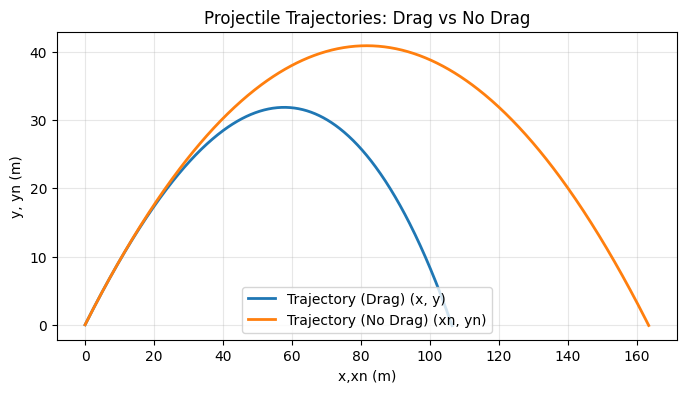

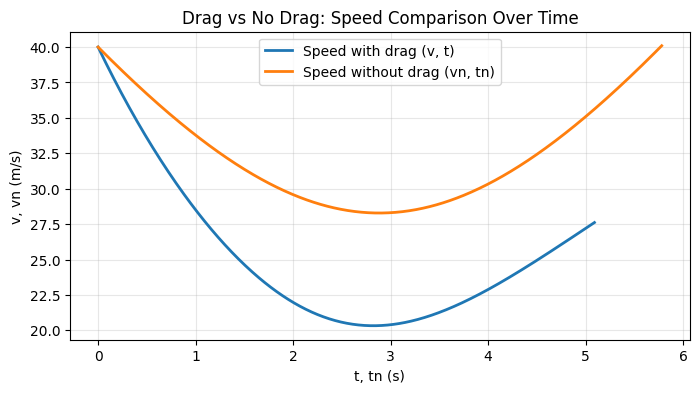

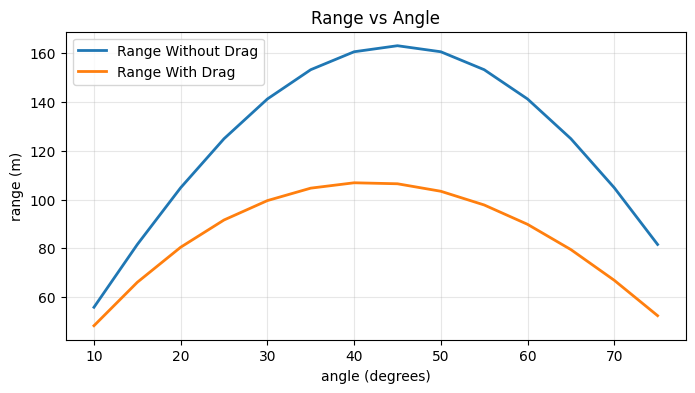

In [58]:
import numpy as np
import matplotlib.pyplot as plt

time_step=0.01
initial_velocity=40
initial_angle=45


def simulate_projectile_drag(v0,theta_deg,dt,b_over_m=0.0046,g=9.81):
    vx=v0*np.cos(theta_deg*np.pi/180)
    vy=v0*np.sin(theta_deg*np.pi/180)
    v=v0

    x,y=0,0
    t=0.0

    t_arr,x_arr,y_arr,vx_arr,vy_arr=[t],[x],[y],[vx],[vy]

    while y>=0:
        x=x+vx*dt
        y=y+vy*dt

        ax=-(b_over_m)*v*vx
        ay=-g-(b_over_m)*v*vy

        vx=vx+ax*dt
        vy=vy+ay*dt
        v=np.sqrt(vx**2+vy**2)

        t=t+dt

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)
    return t_arr,x_arr,y_arr,vx_arr,vy_arr

t,x,y,vx,vy=simulate_projectile_drag(initial_velocity,initial_angle,time_step,b_over_m=0.0046,g=9.81)

tn,xn,yn,vxn,vyn=simulate_projectile_2d(initial_velocity,initial_angle,time_step,g=9.81)

rng_reduction=((np.max(x)-calculator(initial_velocity,initial_angle,a=x,b=y,c=t)[0])/calculator(initial_velocity,initial_angle,a=x,b=y,c=t)[0])*100
max_height_reduction=((np.max(y)-calculator(initial_velocity,initial_angle,a=x,b=y,c=t)[1])/calculator(initial_velocity,initial_angle,a=x,b=y,c=t)[1])*100

print(f'With drag, the range is {np.max(x)} and the max height is {np.max(y)}. \
Without drag, the range is {calculator(initial_velocity,initial_angle,a=xn,b=yn,c=tn)[0]} and the max height is {calculator(initial_velocity,initial_angle,a=xn,b=yn,c=tn)[1]}.\
The presence of drag reduces the range by {rng_reduction}% and the max height by {max_height_reduction}%.')

plt.figure(figsize=(8, 4))
plt.plot(x, y, linewidth=2, label='Trajectory (Drag) (x, y)')
plt.plot(xn, yn, linewidth=2, label='Trajectory (No Drag) (xn, yn)')
plt.xlabel('x,xn (m)')
plt.ylabel('y, yn (m)')
plt.title('Projectile Trajectories: Drag vs No Drag')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

vx = np.array(vx)
vy = np.array(vy)
vxn = np.array(vxn)
vyn = np.array(vyn)

v=np.sqrt(vx**2+vy**2)
vn=np.sqrt(vxn**2+vyn**2)

plt.figure(figsize=(8, 4))
plt.plot(t, v, linewidth=2, label='Speed with drag (v, t)')
plt.plot(tn, vn, linewidth=2, label='Speed without drag (vn, tn)')
plt.xlabel('t, tn (s)')
plt.ylabel('v, vn (m/s)')
plt.title('Drag vs No Drag: Speed Comparison Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

theta=np.arange(10,80,5)
def range(v0,theta_deg=theta):
    rng=0.0
    rng=((v0)**2)*(np.sin(2*(theta_deg*np.pi/180)))/9.81

    rng_drag_arr=[]
    for th in theta:
        rng_drag=np.max(simulate_projectile_drag(initial_velocity,th,time_step,b_over_m=0.0046,g=9.81)[1])
        rng_drag_arr.append(rng_drag)
    return rng, rng_drag_arr

range_no_drag,range_drag=range(40,theta)


plt.figure(figsize=(8, 4))
plt.plot(theta,range_no_drag, linewidth=2, label='Range Without Drag')
plt.plot(theta,range_drag, linewidth=2, label='Range With Drag')
plt.xlabel('angle (degrees)')
plt.ylabel('range (m)')
plt.title('Range vs Angle')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Notes:
(a) The drag force reduces the range dramatically because the force gets stronger quadratically as the speed increases. Without air resistance, velocity reaches its minimum at the peak of the arc, so when there is air resistance, the force is strongest at the beginning and ends of the arc. This results in the trajectory be squished horizontally and pulled backwards a certain amount, while the beginning trajectories are in agreement.

(b) In our simulation, we found that 40 degrees is the optimal angle given our set-up with air resistance, rather than the usual 45 degrees without air resistance. There is therefore a slight preference for horizontal motion, and this is so because the force is weakest at the peak of the arc; if that peak or near-peak is extended, then more ground can be covered. Hence, the parabola is flattened along the y-axis, or the angle relative to the x-axis is smaller.

(c) The Euler method seems rather good or even ideal for these types of problems. However, I can imagine this could become a problem if the system is highly complex: where trajectories are not smooth, forces have too many dependencies and the order of updates becomes undecidable, or there are plain too many forces for this direct method of computation. 

Bonus-- The Homerun Problem

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time_step=0.01
initial_velocity=45
x_min=120
y_min=3

theta=np.arange(0,90,1)


    

TypeError: '>=' not supported between instances of 'tuple' and 'int'